CIS 5190 (Applied Machine Learning) Final Project



The purpose of this project was to categorize fox/nbc news headlines based on training data that was collected. This meant experimenting with many model types (LLMs, LSTMs, and simpler methods) and evaluating performance. As an "exploratory component," I then experimented with fine-tuning the model and using then using it to try and categorize articles from other sources (cnn, dailywire, and npr) to see if headlines had some sort of political bias. The code for cleaning scraped data, training, and evaluating the models is shown below.

#Data Collection and Preprocessing



## Fox News/NBC News Web Scrape

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import random
import re
import os

In [ ]:
# 1. SETUP DIRECTORY AND LOAD DATA
csv_file_path = 'titles.csv'
try:
    news_df = pd.read_csv(csv_file_path)
except FileNotFoundError:
    print(f"Error: '{csv_file_path}' not found in the current directory.")
    exit()




Error: 'titles.csv' not found in the current directory.


In [ ]:
# 2. FIX SPECIFIC ROW (If it exists)
if 2376 in news_df.index:
    pattern = r"^(.*)/"
    # Ensure we treat the URL as a string to avoid errors
    url_val = str(news_df.loc[2376, 'url'])
    match = re.search(pattern, url_val)
    if match:
        news_df.loc[2376, 'url'] = match.group(1)
# Initialize global counter
processed_count = 0

NameError: name 'news_df' is not defined

In [ ]:
# 3. SESSION SETUP
session = requests.Session()
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1',
    'Referer': 'https://www.google.com/'
}
session.headers.update(headers)

In [ ]:
# 4. DEFINING THE FUNCTION
def get_title_and_source(url):
    global processed_count
    processed_count += 1

    # Initialize variables at the TOP so they always exist
    result_title = ""
    news_source = "Unknown"
    url_clean = ""

    # Clean URL
    if isinstance(url, str):
        url_clean = url.replace(".print", "")
    else:
        result_title = "Invalid URL"
        url_clean = str(url)

    # Detect Source (Do this BEFORE request so we know it even if request fails)
    if 'foxnews.com' in url_clean:
        news_source = 'Fox'
    elif 'nbcnews.com' in url_clean:
        news_source = 'NBC'

    # Request Logic

    if result_title == "":
        try:
            delay = random.gauss(5.5, 1.5)
            delay = max(1, min(10, delay))
            time.sleep(delay)
            response = session.get(url_clean, timeout=15)
            if response.status_code == 200:
                soup = BeautifulSoup(response.text, "html.parser")
                title_tag = None

                # Logic to find title based on source
                if news_source == 'Fox':
                    title_tag = soup.find("h1", class_="headline speakable")
                elif news_source == 'NBC':
                    title_tag = soup.find("h1", class_="article-hero-headline__htag")

                # Fallback
                if not title_tag:
                    title_tag = soup.find("h1")
                if title_tag:
                    result_title = title_tag.text.strip()
                else:
                    result_title = "Title Tag Not Found"
            else:
                result_title = f"Error: Status {response.status_code}"
        except Exception as e:
            result_title = f"Connection Failed: {e}"

    # Status File Update
    if processed_count % 100 == 0:
        try:
            with open("status.txt", "w", encoding="utf-8") as f:
                f.write(f"Index: {processed_count}\n")
                f.write(f"URL: {url_clean}\n")
                f.write(f"Title: {result_title}\n")
        except Exception as e:
            pass

    return result_title, news_source

In [ ]:
# 5. EXECUTION
print("Scraping titles and sources...")

# Now the function name matches the definition above
dataset = news_df['url'].apply(lambda x: pd.Series(get_title_and_source(x), index=['title', 'news_source']))
dataset.to_csv('titles_fixed.csv', index=False)
final_df = pd.concat([news_df, dataset], axis=1)
print("Done! Saved to titles_fixed.csv")

## CNN/NPR/DailyWire Web Scrape

In [ ]:
# @title EDA from CNN, Daily Wire, NPR
# !pip install aiohttp pandas

import aiohttp
import asyncio
import pandas as pd
import re
import random
import os
import time
from datetime import datetime

# --- CONFIGURATION ---
OUTPUT_FILE = "eda_slugs.csv"

# Phase 1: Blitz (Fast, for easy targets)
P1_CONFIG = {
    'concurrency': 10,
    'base_wait': 4.0,
    'retries': 2,
    'timeout': 15,
    'backoff_factor': 2
}

# Phase 2: Rescue (Slow, for stubborn/blocked targets)
P2_CONFIG = {
    'concurrency': 3,
    'base_wait': 8.0,
    'retries': 5,
    'timeout': 30,
    'backoff_factor': 3.0
}

USER_AGENTS = [
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 14_1) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.1 Safari/605.1.15',
    'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
]

# Regex Patterns
XML_LOC_PATTERN = re.compile(r'<(?:loc|link)>(https?://[^<]+)</(?:loc|link)>')

def get_headers():
    return {
        'User-Agent': random.choice(USER_AGENTS),
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    }

def extract_slug_by_source(url, source):
    try:
        clean = url.split('?')[0].strip()

        if source == 'cnn':
            # Example: https://www.cnn.com/2025/12/13/us/kentucky-cold-case-solved-michelle-newton
            # Slug: kentucky-cold-case-solved-michelle-newton
            return clean.rstrip('/').split('/')[-1]

        elif source == 'npr':
            return clean.rstrip('/').split('/')[-1]

        elif source == 'dailywire':
            return clean.rstrip('/').split('/')[-1]

        return ""
    except:
        return ""

def validate_url(url, source):
    """
    Filters out unwanted URLs based on source rules
    """
    if source == 'dailywire':
        if url.strip().rstrip('/') == "https://www.dailywire.com":
            return False
        if "/news/" not in url:
            return False

    # CNN validation: Ensure it looks like an article (has year/month)
    if source == 'cnn':
        if "cnn.com" not in url:
            return False
        # Simple check to avoid non-article links if they exist in news.xml
        # The user example has a year, so we can optionally check for digits
        # but sticking to basics is safer unless it grabs junk.

    return True

async def fetch_sitemap(session, task_info, semaphore, config):
    url = task_info['url']
    source = task_info['source']
    current_wait = config['base_wait']

    async with semaphore:
        await asyncio.sleep(random.uniform(0.5, 2.0))

        for attempt in range(1, config['retries'] + 1):
            try:
                await asyncio.sleep(random.uniform(current_wait, current_wait * 1.5))

                async with session.get(url, headers=get_headers(), timeout=config['timeout']) as response:
                    if response.status == 200:
                        content = await response.text()
                        found_urls = XML_LOC_PATTERN.findall(content)

                        rows = []
                        for link in found_urls:
                            if validate_url(link, source):
                                slug = extract_slug_by_source(link, source)
                                if slug:
                                    rows.append({
                                        'source': source,
                                        'url': link,
                                        'slug': slug
                                    })
                        return True, rows, task_info

                    elif response.status in [403, 429, 503]:
                        pass

            except Exception as e:
                pass

            if attempt < config['retries']:
                current_wait *= config['backoff_factor']

    return False, [], task_info

async def run_batch(session, map_list, phase_name, config):
    if not map_list:
        print(f"[{phase_name}] No maps to process.")
        return []

    print(f"\n>>> STARTING {phase_name.upper()} (Maps: {len(map_list)} | Conc: {config['concurrency']})")

    sem = asyncio.Semaphore(config['concurrency'])
    tasks = []

    for item in map_list:
        coro = fetch_sitemap(session, item, sem, config)
        tasks.append(asyncio.create_task(coro))

    failed_items = []
    total_saved_phase = 0

    for future in asyncio.as_completed(tasks):
        success, rows, info = await future
        short_url = info['url'].split('?')[0].split('/')[-1]
        src = info['source'].upper()

        if success:
            if rows:
                df = pd.DataFrame(rows)
                header = not os.path.exists(OUTPUT_FILE)
                df.to_csv(OUTPUT_FILE, mode='a', header=header, index=False)

                count = len(rows)
                total_saved_phase += count
                print(f"[{phase_name}] [{src}] \u2705 Saved {count} slugs | {short_url}")
            else:
                print(f"[{phase_name}] [{src}] \u26A0\ufe0f Empty map | {short_url}")
        else:
            failed_items.append(info)
            print(f"[{phase_name}] [{src}] \u274C FAILED | {short_url}")

    print(f"[{phase_name}] Finished. Total Saved: {total_saved_phase}. Failures: {len(failed_items)}")
    return failed_items

# --- INDEX FETCHERS ---

async def get_npr_indices(session):
    index_url = "https://www.npr.org/live-updates/sitemap.xml"
    print("...Fetching NPR Sitemap Index...")
    try:
        async with session.get(index_url, headers=get_headers()) as r:
            if r.status == 200:
                txt = await r.text()
                all_urls = XML_LOC_PATTERN.findall(txt)
                target_maps = [u for u in all_urls if re.search(r'sitemap-\d{6}\.xml', u)]
                print(f"-> Found {len(target_maps)} NPR archive sitemaps.")
                return [{'url': u, 'source': 'npr'} for u in target_maps]
            else:
                print(f"-> Failed to fetch NPR Index: {r.status}")
                return []
    except Exception as e:
        print(f"-> NPR Index Exception: {e}")
        return []

async def main():
    start_time = time.time()

    if not os.path.exists(OUTPUT_FILE):
        with open(OUTPUT_FILE, 'w') as f:
            f.write("source,url,slug\n")

    async with aiohttp.ClientSession() as session:
        # 1. Prep
        npr_maps = await get_npr_indices(session)

        # CNN is now a direct single map, treated like DailyWire
        cnn_maps = [{'url': "https://www.cnn.com/sitemap/news.xml", 'source': 'cnn'}]

        # DailyWire is a single RSS feed
        dw_maps = [{'url': "https://www.dailywire.com/feeds/rss.xml", 'source': 'dailywire'}]

        all_maps = cnn_maps + npr_maps + dw_maps
        random.shuffle(all_maps)

        # 2. Blitz
        failed_phase1 = await run_batch(session, all_maps, "Phase 1", P1_CONFIG)

        # 3. Rescue
        if failed_phase1:
            print("\n!!! Initiating Rescue Protocol...")
            print("...Cooling down 10s...")
            await asyncio.sleep(10)

            final_failures = await run_batch(session, failed_phase1, "Phase 2", P2_CONFIG)

            if final_failures:
                print(f"\n\u274C PERMANENT FAILURES ({len(final_failures)}):")
                for f in final_failures:
                    print(f" - {f['url']}")
            else:
                print("\n\u2b50 ALL RESCUED.")

    print(f"\nTotal Runtime: {(time.time() - start_time):.2f}s")


await main()

...Fetching NPR Sitemap Index...
-> Found 41 NPR archive sitemaps.

>>> STARTING PHASE 1 (Maps: 43 | Conc: 10)
[Phase 1] [NPR] ✅ Saved 1 slugs | sitemap-202208.xml
[Phase 1] [NPR] ✅ Saved 11 slugs | sitemap-202205.xml
[Phase 1] [NPR] ✅ Saved 8 slugs | sitemap-202310.xml
[Phase 1] [NPR] ✅ Saved 7 slugs | sitemap-202308.xml
[Phase 1] [NPR] ✅ Saved 6 slugs | sitemap-202301.xml
[Phase 1] [NPR] ✅ Saved 1 slugs | sitemap-202504.xml
[Phase 1] [NPR] ✅ Saved 7 slugs | sitemap-202206.xml
[Phase 1] [NPR] ✅ Saved 4 slugs | sitemap-202212.xml
[Phase 1] [NPR] ✅ Saved 1 slugs | sitemap-202406.xml
[Phase 1] [NPR] ✅ Saved 8 slugs | sitemap-202306.xml
[Phase 1] [NPR] ✅ Saved 1 slugs | sitemap-202309.xml
[Phase 1] [NPR] ✅ Saved 8 slugs | sitemap-202210.xml
[Phase 1] [NPR] ✅ Saved 7 slugs | sitemap-202211.xml
[Phase 1] [NPR] ✅ Saved 27 slugs | sitemap-202204.xml
[Phase 1] [NPR] ✅ Saved 1 slugs | sitemap-202404.xml
[Phase 1] [NPR] ✅ Saved 1 slugs | sitemap-202305.xml
[Phase 1] [NPR] ✅ Saved 18 slugs | site

In [ ]:
eda_df = pd.read_csv('eda_slugs.csv')


In [ ]:
eda_df = eda_df[~eda_df['slug'].str.contains('morning-edition')]

In [ ]:
eda_df['source'].value_counts()

,count
source,
npr,440
cnn,111
dailywire,100


##Loading CSVs in and preprocessing

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/news_slugs_master.csv'  #Might have to change this for your drive


KeyboardInterrupt: 

In [ ]:
import pandas as pd
df = pd.read_csv(file_path)
df.drop_duplicates(inplace=False)


,source,url,slug
0,nbc,https://www.nbcnews.com/news/nbcblk/jewell-jon...,jewell-jones-youngest-black-state-lawmaker-ame...
1,nbc,https://www.nbcnews.com/business/business-news...,judge-approves-25-million-settlement-trump-uni...
2,nbc,https://www.nbcnews.com/news/us-news/15-surviv...,15-survivors-seek-250m-plus-deadly-biloxi-trai...
3,nbc,https://www.nbcnews.com/news/us-news/did-terro...,did-terrorists-learn-how-get-laptops-past-airp...
4,nbc,https://www.nbcnews.com/health/health-news/myl...,mylan-says-epipen-manufacturing-partner-expand...
...,...,...,...
3951818,fox,https://www.foxnews.com/world/german-officials...,german-officials-condemn-store-owner-declared-...
3951819,fox,https://www.foxnews.com/lifestyle/rabbi-honors...,rabbi-honors-charlie-kirks-enduring-legacy-def...
3951820,fox,https://www.foxnews.com/sports/aces-star-aja-w...,aces-star-aja-wilson-makes-wnba-history-after-...
3951821,fox,https://www.foxnews.com/world/uk-canada-austra...,uk-canada-australia-recognize-palestinian-stat...


In [ ]:
# Split df['slug'] on '-'
df['slug'] = df['slug'].str.split('-')




KeyError: True

In [ ]:
#Remove all rows in df where ['slug'] is in an array of length <= 2
df = df[df['slug'].apply(lambda x: len(x) > 2)]

In [ ]:
import pandas as pd
import re

# 1. Remove last element if it starts with "flna"
# Fix: Check if list has content (x) before checking x[-1]
df['slug'] = df['slug'].apply(lambda x: x[:-1] if (x and x[-1].startswith('flna')) else x)
df = df[df['slug'].apply(lambda x: len(x) > 0)]

# 2. Remove last element if it is NOT "n" followed by numbers
# Fix: Check if list has content (x)
df['slug'] = df['slug'].apply(lambda x: x[:-1] if (x and not re.match(r'n\d+$', x[-1])) else x)
df = df[df['slug'].apply(lambda x: len(x) > 0)]

# 3. Remove first element if it consists of digits and is >= 7
# Fix: Check if list has content (x) before checking x[0]
# Note: Assuming you meant the integer value is >= 7. If you meant length, use len(x[0]) >= 7
df['slug'] = df['slug'].apply(lambda x: x[1:] if (x and x[0].isdigit() and int(x[0]) >= 7) else x)
df = df[df['slug'].apply(lambda x: len(x) > 0)]

# 4. Remove last element if it consists of digits and is >= 7
# Fix: Check if list has content (x) before checking x[-1]
df['slug'] = df['slug'].apply(lambda x: x[:-1] if (x and x[-1].isdigit() and int(x[-1]) >= 7) else x)
df = df[df['slug'].apply(lambda x: len(x) > 0)]

/tmp/ipython-input-3530104675.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['slug'] = df['slug'].apply(lambda x: x[:-1] if (x and x[-1].startswith('flna')) else x)
/tmp/ipython-input-3530104675.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['slug'] = df['slug'].apply(lambda x: x[:-1] if (x and not re.match(r'n\d+$', x[-1])) else x)


In [ ]:
#merge slug back into string

df['slug'] = df['slug'].apply(lambda x: ' '.join(x))

#lowercase slug
df['slug'] = df['slug'].str.lower()

#save df to drive
df.to_csv('/content/drive/MyDrive/fox_nbc_slugs_CLEANED.csv', index=False)

In [ ]:
eda_slugs = pd.read_csv('/content/drive/MyDrive/eda_slugs.csv')

In [ ]:
eda_slugs.drop_duplicates(inplace=True)

#remove all rows in eda slugs that being with "morning-edition"
eda_slugs = eda_slugs[~eda_slugs['slug'].str.startswith('morning-edition')]


#remove the ending of slugs where ending is (4d)-(2d)-(2d)
eda_slugs['slug'] = eda_slugs['slug'].str.replace(r'\(4d\)-\(2d\)-\(2d\)$', '', regex=True)

#split slug into array of strings
eda_slugs['slug'] = eda_slugs['slug'].str.split('-')


#remove rows where slug array len <=2
eda_slugs = eda_slugs[eda_slugs['slug'].apply(lambda x: len(x) > 2)]
eda_slugs
#merge slug back into string
eda_slugs['slug'] = eda_slugs['slug'].apply(lambda x: ' '.join(x))

#lowercase slug
eda_slugs['slug'] = eda_slugs['slug'].str.lower()

#save to drive
eda_slugs.to_csv('/content/drive/MyDrive/eda_slugs_CLEANED.csv', index=False)

#Model Experimentation

## Load Cleaned CSVs

In [ ]:
import pandas as pd
import numpy as np
import re
import os
from urllib.parse import urlparse

input_file = '/news_slugs_master.csv'

if os.path.exists(input_file):
    print("ERROR!")
else:
    df = pd.read_csv('/content/drive/MyDrive/news_slugs_master.csv')
    df.columns = [c.lower() for c in df.columns]

    # source identification
    def get_source(row):
        if 'source' in row.index and isinstance(row['source'], str):
            s = row['source'].lower()
            if 'fox' in s: return 'fox'
            if 'nbc' in s: return 'nbc'
        u = str(row['url']).lower()
        if 'foxnews' in u: return 'fox'
        if 'nbcnews' in u: return 'nbc'
        return 'other'

    df['source'] = df.apply(get_source, axis=1)

    # cleaning
    def get_clean_slug(row):
        try:
            url = str(row['url'])
            path = urlparse(url).path.strip("/")
            raw_slug = path.split("/")[-1]

            # Remove extensions
            if raw_slug.endswith(".print"): raw_slug = raw_slug[:-6]
            if raw_slug.endswith(".html"): raw_slug = raw_slug[:-5]

            # Split by hyphens
            parts = raw_slug.split('-')

            # If it's NBC, check the last part.
            # If the last part contains ANY digit, it's likely an ID (flna123, n123, rcna123).
            # Fox News slugs rarely end in digits unless it's a year (2024),
            # but NBC IDs are almost always mixed-alphanumeric or pure numeric.
            if row['source'] == 'nbc' and len(parts) > 1:
                last_part = parts[-1]
                # Regex: Contains at least one digit
                if re.search(r'\d', last_part):
                    parts.pop() # Remove the last part (the ID)

            # Rejoin with spaces and Title Case
            return " ".join(parts).title()
        except:
            return ""

    # apply cleaning
    print("Extracting and cleaning slugs...")
    df['slug'] = df.apply(get_clean_slug, axis=1)

    # sample 50k each
    fox_df = df[df['source'] == 'fox']
    nbc_df = df[df['source'] == 'nbc']

    print(f"Fox rows available: {len(fox_df)}")
    print(f"NBC rows available: {len(nbc_df)}")

    N_SAMPLES = 50000
    fox_subset = fox_df.sample(n=min(len(fox_df), N_SAMPLES), random_state=42)
    nbc_subset = nbc_df.sample(n=min(len(nbc_df), N_SAMPLES), random_state=42)

    # Combine
    df_final = pd.concat([fox_subset, nbc_subset])
    df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

    # save
    df_export = df_final[['source', 'url', 'slug']]
    output_filename = 'fox_nbc_slugs_CLEANED.csv'
    df_export.to_csv(output_filename, index=False)

    print(f"Created '{output_filename}'")
    print(df_export.head())

In [ ]:
from google.colab import files
files.download('submission_model.zip')

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

## Simple Methods: Logistic Regression, Naive Bayes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
import os



In [ ]:
#params
CSV_PATH = 'titles_fixed_with_news_source.csv'
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
TFIDF_MAX_FEATURES = 100
LOGREG_MAX_ITER = 100
BASELINE_LINE = 0.6649



In [ ]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV file not found at '{CSV_PATH}'. Make sure you saved the scraped titles to this filename.")

df = pd.read_csv(CSV_PATH)
print("Columns in CSV:", df.columns.tolist())
if 'title' not in df.columns or 'news_source' not in df.columns:
    raise KeyError("CSV must contain columns named 'title' and 'news_source' (case-sensitive).")



Columns in CSV: ['title', 'news_source']


In [ ]:
def normalize_label(x):
    if not isinstance(x, str):
        return x
    x_lower = x.strip().lower()
    if re.search(r'\bfox\b', x_lower) or 'foxnews' in x_lower or 'fox news' in x_lower:
        return 0  # FoxNews -> 0
    if re.search(r'\bnbc\b', x_lower) or 'nbcnews' in x_lower or 'nbc news' in x_lower:
        return 1  # NBC -> 1
    return x

df = df.copy()
df['title'] = df['title'].fillna('').astype(str)
df['news_label_raw'] = df['news_source'].astype(str)
df['label'] = df['news_label_raw'].apply(normalize_label)

print("\nRaw label value counts:")
print(df['news_label_raw'].value_counts(dropna=False).head(20))
print("\nMapped label distribution (0=Fox, 1=NBC, others = unexpected):")
print(df['label'].value_counts(dropna=False))

unexpected = df[~df['label'].isin([0,1])]
if len(unexpected) > 0:
    print(f"\nWarning: {len(unexpected)} rows have unexpected label values (not mapped to 0/1).")
    print(unexpected[['news_source','label']].drop_duplicates().head(10))

df = df[df['label'].isin([0,1])].reset_index(drop=True)
X = df['title']
y = df['label']




Raw label value counts:
news_label_raw
Fox    2000
NBC    1805
Name: count, dtype: int64

Mapped label distribution (0=Fox, 1=NBC, others = unexpected):
label
0    2000
1    1805
Name: count, dtype: int64


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 3044, Test size: 761


In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=TFIDF_MAX_FEATURES)),
    ('lr', LogisticRegression(max_iter=LOGREG_MAX_ITER))
])

In [ ]:
print("\nTraining baseline pipeline...")
pipeline.fit(X_train, y_train)




Training baseline pipeline...


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=100, stop_words='english')),
                ('lr', LogisticRegression())])

In [ ]:
#eval
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")

print("\nClassification Report (target labels: 0=Fox, 1=NBC):")
print(classification_report(y_test, y_pred, target_names=['Fox','NBC']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):")
print(cm)




Test Accuracy: 0.6991

Classification Report (target labels: 0=Fox, 1=NBC):
              precision    recall  f1-score   support

         Fox       0.67      0.82      0.74       400
         NBC       0.74      0.56      0.64       361

    accuracy                           0.70       761
   macro avg       0.71      0.69      0.69       761
weighted avg       0.71      0.70      0.69       761

Confusion matrix (rows=true, cols=pred):
[[330  70]
 [159 202]]


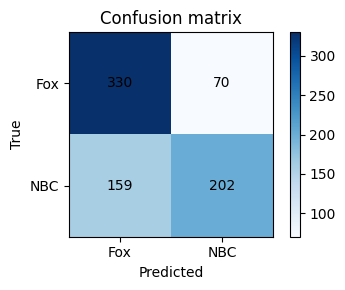

In [ ]:
# confusion matrix
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
plt.xticks([0,1], ['Fox','NBC'])
plt.yticks([0,1], ['Fox','NBC'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i,j]), ha='center', va='center', color='black')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()



In [ ]:
# cross-val
print(f"\nPerforming {CV_FOLDS}-fold cross-validation on the full dataset (pipeline)...")
cv_scores = cross_val_score(pipeline, X, y, cv=CV_FOLDS, scoring='accuracy', n_jobs=-1)
print(f"CV accuracy scores: {cv_scores}")
print(f"CV mean accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")




Performing 5-fold cross-validation on the full dataset (pipeline)...
CV accuracy scores: [0.68068331 0.70827858 0.69382392 0.70959264 0.67674113]
CV mean accuracy: 0.6938 ± 0.0136



Computing learning curve (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

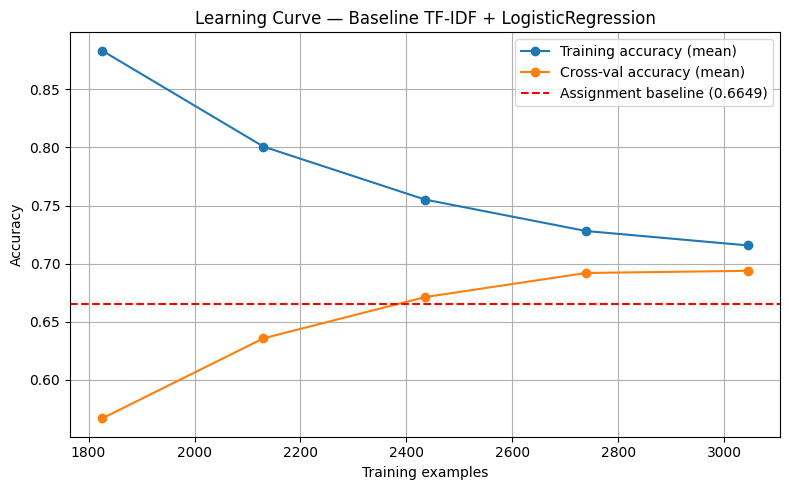

In [ ]:
# learning curve
print("\nComputing learning curve (this may take a moment)...")
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=CV_FOLDS, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', n_jobs=-1, random_state=RANDOM_STATE
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Training accuracy (mean)')
plt.plot(train_sizes, test_mean, 'o-', label='Cross-val accuracy (mean)')
plt.axhline(y=BASELINE_LINE, color='red', linestyle='--', label=f"Assignment baseline ({BASELINE_LINE:.4f})")
plt.title('Learning Curve — Baseline TF-IDF + LogisticRegression')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# save
MODEL_OUT = 'baseline_tfidf_logreg.pkl'
joblib.dump(pipeline, MODEL_OUT)
print(f"\nSaved trained pipeline to {MODEL_OUT}")


Saved trained pipeline to baseline_tfidf_logreg.pkl

Baseline reproduction complete. If you want me to also run a TF-IDF+LogReg with exactly the assignment's lambda mapping (the source code snippet had a different mapping), I can run that as well.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score



In [ ]:
# load
df = pd.read_csv('titles_fixed_with_news_source.csv')

print("Columns found in CSV:", df.columns.tolist())



Columns found in CSV: ['title', 'news_source']


In [ ]:
# prep
try:
    X = df['title']
    y = df['news_source']
except KeyError as e:
    print(f"\nError: The script couldn't find the column {e}.")
    print("Please make sure the headers in your CSV match exactly.")
    exit()

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:

model = make_pipeline(CountVectorizer(), MultinomialNB())

print("Training model...")
model.fit(X_train, y_train)



Training model...


Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [ ]:
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")



Accuracy: 0.81


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('titles_fixed_with_news_source.csv')

X = df['title']
y = df['news_source']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split successfully.")

Data loaded and split successfully.


In [ ]:
model = make_pipeline(CountVectorizer(), MultinomialNB())
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"Current Model Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("---")

Current Model Accuracy: 0.8068
---



Generating Learning Curve... (This might take a moment)


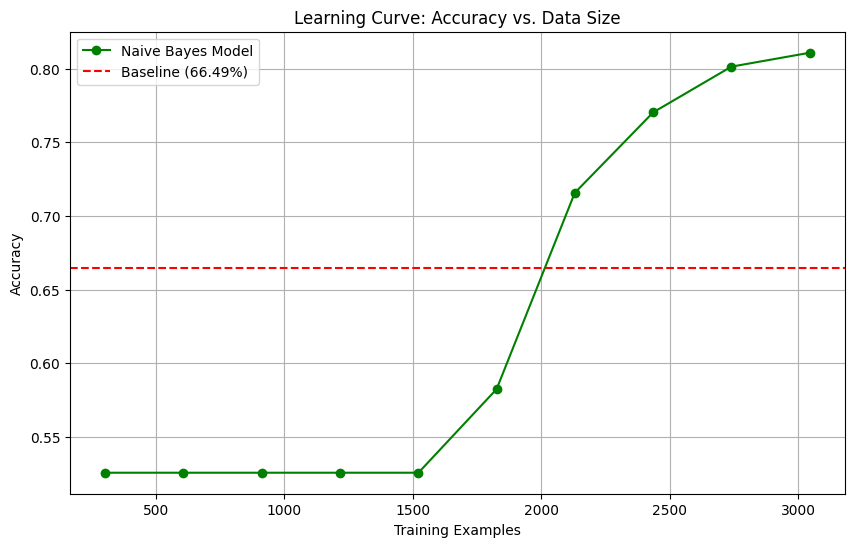

In [ ]:
# Learning Curve
print("\nGenerating Learning Curve... (This might take a moment)")

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Naive Bayes Model")
plt.axhline(y=0.6649, color='red', linestyle='--', label="Baseline (66.49%)")

plt.title("Learning Curve: Accuracy vs. Data Size")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

## Lightweight Transformer Model

In [ ]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.utils import shuffle
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# load slugs
df = pd.read_csv('/content/drive/MyDrive/fox_nbc_slugs_CLEANED.csv')

# train/test split
train_df, test_df = train_test_split(df[['slug_clean','label']], test_size=0.2, random_state=SEED, stratify=df['label'])

# Huggingface Dataset
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Tokenizer + model
model_checkpoint = "google/electra-small-discriminator"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
max_length = 64

def preprocess_function(examples):
    return tokenizer(examples["slug_clean"], truncation=True, padding="max_length", max_length=max_length)

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

# metrics
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# TrainingArguments
from transformers import TrainingArguments, Trainer
args = TrainingArguments(
    output_dir="electra-small-news",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_strategy="epoch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
print(trainer.evaluate())

## Bi-Directional LSTM

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from collections import Counter

# --- 1. CONFIGURATION ---
BATCH_SIZE = 64
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
LEARNING_RATE = 0.001
EPOCHS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load slugs
df = pd.read_csv('/content/drive/MyDrive/fox_nbc_slugs_CLEANED.csv')

# Fix formatting (Hyphens to spaces)
df['slug'] = df['slug'].astype(str).str.replace('-', ' ')

# Hygiene Filtering
df['word_count'] = df['slug'].apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 4]
junk_words = ["Video", "Transcript", "Watch", "Live", "Index", "Home"]
df = df[~df['slug'].isin(junk_words)]

# Label Mapping
label_map = {"fox": 0, "fox news": 0, "foxnews": 0, "nbc": 1, "nbc news": 1, "nbcnews": 1}
df['source'] = df['source'].astype(str).str.lower().str.strip()
df['label'] = df['source'].map(label_map)
df = df.dropna(subset=['slug', 'label'])
df['label'] = df['label'].astype(int)

# Split Data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['slug'].values, df['label'].values, test_size=0.2, random_state=42
)

# vocab builder
all_text = " ".join(X_train_raw)
words = all_text.split()
word_counts = Counter(words)

# Special tokens
vocab = {"<PAD>": 0, "<UNK>": 1}

# Add unique words to vocab
for word in word_counts:
    if word not in vocab:
        vocab[word] = len(vocab)

print(f"Total Unique Words (Vocab Size): {len(vocab)}")

# Find the longest slug in the training set to not cut anything off
max_slug_len = max([len(slug.split()) for slug in X_train_raw])
print(f"Longest Sequence in Data: {max_slug_len} words")
MAX_SEQ_LEN = max_slug_len

# Tokenizer Function
def encode_text(text_list, vocab, max_len):
    encoded_data = []
    for text in text_list:
        tokens = text.split()
        # Convert word to ID
        encoded = [vocab.get(t, vocab["<UNK>"]) for t in tokens]

        # Padding only
        if len(encoded) < max_len:
            encoded += [vocab["<PAD>"]] * (max_len - len(encoded))
        else:
            # Just in case test set has a freakishly long outlier
            encoded = encoded[:max_len]

        encoded_data.append(encoded)
    return np.array(encoded_data)

# Encode Datasets
X_train_enc = encode_text(X_train_raw, vocab, MAX_SEQ_LEN)
X_test_enc = encode_text(X_test_raw, vocab, MAX_SEQ_LEN)

# pytorch dataset
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = NewsDataset(X_train_enc, y_train)
test_dataset = NewsDataset(X_test_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# model definition
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(embeds)
        # Concatenate forward and backward hidden states from the last time step
        hidden = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1)
        output = self.fc(hidden)
        return self.sigmoid(output)

model = BiLSTMClassifier(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# training loop
print(f"--- STARTING TRAINING ON {DEVICE} ---")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

# eval
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).cpu().numpy()
        preds_binary = (preds > 0.5).astype(int)
        all_preds.extend(preds_binary)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

print("\n--- Bi-LSTM FINAL RESULTS ---")
acc = accuracy_score(all_labels, all_preds)
p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")

## DistilBert

###Install Dependencies

In [ ]:
!pip install transformers datasets accelerate scikit-learn

In [ ]:
import torch
from google.colab import files

# Save weights of the fine-tuned model
torch.save(trainer.model.state_dict(), "model.pt")

# Download to local machine
files.download('model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Load and Prepare Data

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Load the CLEANED dataset
# This file contains the 100k balanced rows with NBC IDs removed.
df = pd.read_csv('fox_nbc_slugs_CLEANED.csv')

# Map Labels (0 for Fox, 1 for NBC)
# Our cleaning step ensured 'source' is strictly 'fox' or 'nbc', so this map works perfectly.
label_map = {"fox": 0, "nbc": 1}
df['label'] = df['source'].map(label_map)

# Filter any rows that might have failed preprocessing
df = df.dropna(subset=['slug', 'label'])
df['label'] = df['label'].astype(int)

# train/test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(f"Training Samples: {len(train_dataset)}")
print(f"Testing Samples: {len(test_dataset)}")
print("Sample Data:", train_dataset[0])

Training Samples: 79890
Testing Samples: 19973
Sample Data: {'source': 'fox', 'url': 'https://www.foxnews.com/us/alabama-woman-concerned-over-social-media-posts-against-daughter-family', 'slug': 'Alabama Woman Concerned Over Social Media Posts Against Daughter Family', 'label': 0, '__index_level_0__': 62350}


###Tokenization

In [ ]:
from transformers import AutoTokenizer

# Load the DistilBERT tokenizer
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    return tokenizer(examples["slug"], truncation=True, padding="max_length", max_length=64)

# apply tokenization to all data
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/79890 [00:00<?, ? examples/s]

Map:   0%|          | 0/19973 [00:00<?, ? examples/s]

###Initialize the Model

In [ ]:
from transformers import AutoModelForSequenceClassification

# Load pre-trained model with 2 output labels (Fox vs NBC)
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###Define Metrics

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Convert logits to class predictions
    preds = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

###Train the Model

In [ ]:
from transformers import TrainingArguments, Trainer

batch_size = 16

# Define training settings
args = TrainingArguments(
    output_dir="bert-political-classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

# Init Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Start Training
print("Starting training...")
trainer.train()

/tmp/ipython-input-1853598514.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.269900,0.248784,0.891253,0.891454,0.880628,0.902550
2,0.192800,0.281147,0.897762,0.900970,0.865059,0.939992
3,0.143800,0.352111,0.895359,0.895823,0.882711,0.909330


TrainOutput(global_step=14982, training_loss=0.2187832363965339, metrics={'train_runtime': 456.3434, 'train_samples_per_second': 525.197, 'train_steps_per_second': 32.831, 'total_flos': 3968557679485440.0, 'train_loss': 0.2187832363965339, 'epoch': 3.0})

###Final Evaluation

In [ ]:
results = trainer.evaluate()

print("\n--- FINAL RESULTS ---")
print(f"Accuracy:  {results['eval_accuracy']:.4f}")
print(f"F1 Score:  {results['eval_f1']:.4f}")
print(f"Precision: {results['eval_precision']:.4f}")
print(f"Recall:    {results['eval_recall']:.4f}")

# custom example
def predict_headline(headline):
    inputs = tokenizer(headline, return_tensors="pt", truncation=True, padding=True).to(model.device)
    outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)
    pred_label = torch.argmax(probs, dim=-1).item()
    label_name = "NBC News" if pred_label == 1 else "Fox News"
    return label_name, probs.max().item()

import torch
sample_headline = "Senate passes new bill in late night session"
prediction, confidence = predict_headline(sample_headline)
print(f"\nTest Headline: '{sample_headline}'")
print(f"Prediction: {prediction} ({confidence:.2%} confidence)")


--- FINAL RESULTS ---
Accuracy:  0.8913
F1 Score:  0.8915
Precision: 0.8806
Recall:    0.9026

Test Headline: 'Senate passes new bill in late night session'
Prediction: Fox News (99.59% confidence)


In [ ]:
torch.save(trainer.model.state_dict(), "model.pt")

#Exploratory Component: Tuning to other news identification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_path = "/content/drive/MyDrive/bert_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=2,           # new 3-class head
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

#freeze all
for param in model.parameters():
    param.requires_grad = False

#unfreeze last 2 layers
for layer in model.distilbert.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

#unfreeze head
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable: {trainable:,}")
print(f"Total:     {total:,}")
print(f"Percent:   {100 * trainable / total:.2f}%")



Trainable: 14,177,282
Total:     66,955,010
Percent:   21.17%


In [ ]:
#load & preprocess new dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
import re
from sklearn.utils import resample


# Load the dataset
eda_df = pd.read_csv(model_path+'/eda_slugs.csv')
eda_df = eda_df[~eda_df['slug'].str.contains('morning-edition')]

# label_map = {"dailywire": 0, "npr": 1, "cnn": 2}
label_map = {"dailywire": 0, "npr": 1, "cnn": 1}
eda_df['label'] = eda_df['source'].map(label_map)

# Filter
eda_df = eda_df.dropna(subset=['slug', 'label'])
eda_df['label'] = eda_df['label'].astype(int)

eda_df['slug'] = eda_df['slug'].apply(lambda x: re.sub(r'-\d{4}-\d{2}-\d{2}$', '', x))

# train/test split
train_df, test_df = train_test_split(eda_df, test_size=0.2, random_state=42)

dailywire_df = train_df[train_df['label'] == 0]
majority_df = train_df[train_df['label'] == 1]

dailywire_upsampled = resample(
    dailywire_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=42
)

train_df_balanced = pd.concat([dailywire_upsampled, majority_df])
train_dataset = Dataset.from_pandas(train_df)

#convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


import numpy as np
print(np.bincount(train_dataset['label']))

print(f"Training Samples: {len(train_dataset)}")
print(f"Testing Samples: {len(test_dataset)}")
print("Sample Data:", train_dataset[400])
print(train_dataset.to_pandas()['source'].value_counts())


[ 79 441]
Training Samples: 520
Testing Samples: 131
Sample Data: {'source': 'npr', 'url': 'https://www.npr.org/live-updates/russia-invades-ukraine-2022-03-20', 'slug': 'russia-invades-ukraine', 'label': 1, '__index_level_0__': 778}
source
npr          354
cnn           87
dailywire     79
Name: count, dtype: int64


In [ ]:
def preprocess_function(examples):
    return tokenizer(examples["slug"], truncation=True, padding="max_length", max_length=64)

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

Map:   0%|          | 0/131 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
#training
from transformers import TrainingArguments, Trainer

batch_size = 16

# Define training settings
args = TrainingArguments(
    output_dir="bert-political-classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)


# Init Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Start Training
print("Starting training...")
trainer.train()

/tmp/ipython-input-1062522410.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.811200,0.928722,0.412214,0.461538,1.000000,0.300000
2,0.670100,0.507715,0.893130,0.932039,1.000000,0.872727
3,0.472800,0.371749,0.961832,0.977376,0.972973,0.981818
4,0.371200,0.239553,0.969466,0.981651,0.990741,0.972727
5,0.286600,0.184416,0.961832,0.977169,0.981651,0.972727
6,0.262400,0.157893,0.961832,0.976959,0.990654,0.963636
7,0.247300,0.149863,0.954198,0.972727,0.972727,0.972727
8,0.230700,0.145681,0.961832,0.977169,0.981651,0.972727


TrainOutput(global_step=264, training_loss=0.5440366213971918, metrics={'train_runtime': 12.5197, 'train_samples_per_second': 332.276, 'train_steps_per_second': 21.087, 'total_flos': 68883047301120.0, 'train_loss': 0.5440366213971918, 'epoch': 8.0})

In [ ]:
#final eval
results = trainer.evaluate()

print("\n--- FINAL RESULTS ---")
print(f"Accuracy:  {results['eval_accuracy']:.4f}")
print(f"F1 Score:  {results['eval_f1']:.4f}")
print(f"Precision: {results['eval_precision']:.4f}")
print(f"Recall:    {results['eval_recall']:.4f}")


--- FINAL RESULTS ---
Accuracy:  0.9618
F1 Score:  0.9772
Precision: 0.9817
Recall:    0.9727



--- GENERATING CLASS-WISE METRICS ---



Classification Report (Per-Class Metrics):
              precision    recall  f1-score   support

   DailyWire       0.86      0.90      0.88        21
     NPR/CNN       0.98      0.97      0.98       110

    accuracy                           0.96       131
   macro avg       0.92      0.94      0.93       131
weighted avg       0.96      0.96      0.96       131


Confusion Matrix (Normalized by Class Support):
[[0.9047619  0.0952381 ]
 [0.02727273 0.97272727]]


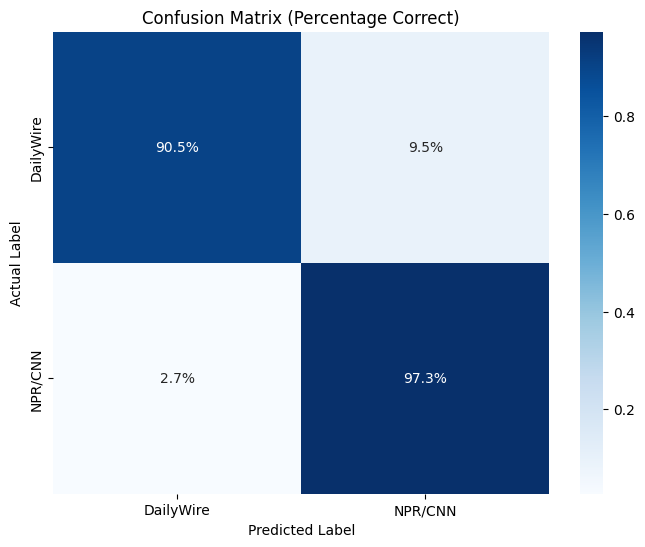

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#predictions on the test set
test_predictions = trainer.predict(tokenized_test)
y_logits = test_predictions.predictions
y_pred = np.argmax(y_logits, axis=1)
y_true = test_predictions.label_ids

class_names = ["DailyWire", "NPR/CNN"]

print("\nClassification Report (Per-Class Metrics):")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate and Normalize Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nConfusion Matrix (Normalized by Class Support):")
print(cm_pct)

try:
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix (Percentage Correct)')
    plt.show()
except Exception as e:
    print(f"Could not display plot: {e}")